# LangGraph

__Автор задач: Блохин Н.В. (NVBlokhin@fa.ru)__

Материалы:
* https://docs.langchain.com/oss/python/langgraph/quickstart
* https://docs.langchain.com/oss/python/langgraph/workflows-agents
* https://docs.langchain.com/oss/python/langgraph/persistence

## Задачи для совместного разбора

1\. Обсудите роль пакета `langgraph` в экосистеме `langchain`, основные возможностью по созданию графа состояний при помощи этого пакета.

In [1]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict
import langgraph

In [2]:
class State(TypedDict):
  day: str
  message: str | None

In [3]:
def generate_message(state: State):
  # ...
  message = "message from state: {}".format(state["day"])
  return {"message": message}

graph = StateGraph(State)

graph.add_node("build_message", generate_message)
# graph.add_node(...)

graph.add_edge(START, "build_message")
# graph.add_edge(...)
graph.add_edge("build_message", END)

app = graph.compile()
app.invoke({"day": "monday"})


{'day': 'monday', 'message': 'message from state: monday'}

In [4]:
class State(TypedDict):
  text: str
  message_en: str | None
  message_ch: str | None

def generate_message_en(state: State):
  # ...
  message = "english message from text: {}".format(state["text"])
  return {"message_en": message}

def generate_message_ch(state: State):
  # ...
  message = "chinese message from text: {}".format(state["text"])
  return {"message_ch": message}

graph = StateGraph(State)

graph.add_node("build_message_en", generate_message_en)
graph.add_node("build_message_ch", generate_message_ch)

graph.add_edge(START, "build_message_en")
graph.add_edge(START, "build_message_ch")

graph.add_edge("build_message_en", END)
graph.add_edge("build_message_ch", END)

app = graph.compile()
app.invoke({"text": "пример текста"})


{'text': 'пример текста',
 'message_en': 'english message from text: пример текста',
 'message_ch': 'chinese message from text: пример текста'}

In [5]:
import random

class State(TypedDict):
  text: str
  message_en: str | None
  message_ch: str | None

def generate_message_en(state: State):
  # ...
  message = "english message from text: {}".format(state["text"])
  return {"message_en": message}

def generate_message_ch(state: State):
  # ...
  message = "chinese message from text: {}".format(state["text"])
  return {"message_ch": message}

def condition(state: State):
  if random.random() <= 0.5:
    return "chinese"
  return "english"


graph = StateGraph(State)

graph.add_node("build_message_en", generate_message_en)
graph.add_node("build_message_ch", generate_message_ch)

graph.add_conditional_edges(
    START,
    condition,
    {
        "chinese": "build_message_ch",
        "english": "build_message_en"
    }
)

graph.add_edge("build_message_en", END)
graph.add_edge("build_message_ch", END)

app = graph.compile()
app.invoke({"text": "пример текста"})


{'text': 'пример текста',
 'message_ch': 'chinese message from text: пример текста'}

In [6]:
app.invoke({"text": "пример текста"})

{'text': 'пример текста',
 'message_ch': 'chinese message from text: пример текста'}

## Задачи для самостоятельного решения

In [24]:
import os
import random
from typing import TypedDict, Literal, Dict, Any, List, Optional
from pydantic import BaseModel, Field

from langchain_core.messages import SystemMessage, HumanMessage
from langchain_core.prompts import ChatPromptTemplate
from langchain_openai import ChatOpenAI
from langchain_core.documents import Document

from langgraph.graph import StateGraph, START, END
from IPython.display import Image, display, Markdown

from langchain_chroma import Chroma
from langchain_huggingface import HuggingFaceEmbeddings
import sqlite3
import re
import pandas as pd

from langchain_community.document_loaders import TextLoader
from langchain_text_splitters import RecursiveCharacterTextSplitter
from dotenv import load_dotenv
load_dotenv()
os.environ["OPENAI_BASE_URL"] = "https://api.proxyapi.ru/openai/v1"

<p class="task" id="1"></p>

1\. Создайте граф с простой последовательностью, который генерирует анекдот на заданную тему.
Для этого создайте 3 узла и последовательно свяжите их:
- узел setup_prompt: формирует сообщение для модели на основе входной темы (topic).
- узел call_model: отправляет сформированный промпт в LLM и получает ответ.
- узел uppercase_parser: забирает сгенерированный текст из ответа моели и переводит его ВЕРХНИЙ РЕГИСТР.
Визуализируйте полученный граф.

Выведите на экран результат работы для нескольких тем.

- [x] Проверено на семинаре

In [8]:
class JokeState(TypedDict):
    topic: str
    prompt: str
    response: str
    result: str

In [9]:
def setup_prompt(state: JokeState):
    prompt = f"Расскажи короткий и смешной анекдот на тему: {state['topic']}"
    return {"prompt": prompt}

def call_model(state: JokeState):
    llm = ChatOpenAI(
        model="gpt-5.4-mini", 
        temperature=0.7
        )
    response = llm.invoke(state["prompt"])
    return {"response": response.content}

def uppercase_parser(state: JokeState):
    return {"result": state["response"].upper()}

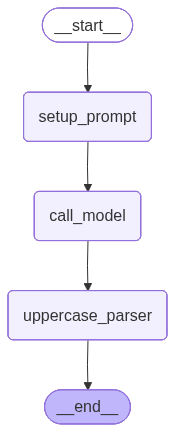

In [10]:
builder_joke = StateGraph(JokeState)

builder_joke.add_node("setup_prompt", setup_prompt)
builder_joke.add_node("call_model", call_model)
builder_joke.add_node("uppercase_parser", uppercase_parser)

builder_joke.add_edge(START, "setup_prompt")
builder_joke.add_edge("setup_prompt", "call_model")
builder_joke.add_edge("call_model", "uppercase_parser")
builder_joke.add_edge("uppercase_parser", END)

graph_joke = builder_joke.compile()

display(Image(graph_joke.get_graph().draw_mermaid_png()))


In [11]:
topics = ["искусственный интеллект", "базы данных", "Слоник PostgreSQL"]
for topic in topics:
    print(f"\nТема: {topic}")
    out = graph_joke.invoke({"topic": topic})
    print(out["result"])


Тема: искусственный интеллект
ИСКУССТВЕННЫЙ ИНТЕЛЛЕКТ ПРИШЁЛ К ВРАЧУ.

ВРАЧ СПРОСИЛ:
— ЧТО ВАС БЕСПОКОИТ?

ИИ ПОДУМАЛ И ОТВЕТИЛ:
— НИЧЕГО. НО Я УЖЕ ПРОВЕРИЛ ВАШИ СИМПТОМЫ И У МЕНЯ ТРЕВОГА.

Тема: базы данных
БАЗА ДАННЫХ ГОВОРИТ ПРОГРАММИСТУ:

— У МЕНЯ ВСЁ ПОД КОНТРОЛЕМ, Я В НОРМЕ.  
— А ПОЧЕМУ ТОГДА ТЫ ТАК МЕДЛЕННО ОТВЕЧАЕШЬ?  
— Я НЕ МЕДЛЮ, Я ПРОСТО ДЕЛАЮ **ПОЛНУЮ ВЫБОРКУ ЖИЗНЕННЫХ РЕШЕНИЙ**.

Тема: Слоник PostgreSQL
СЛОНИК POSTGRESQL ПРИШЁЛ В ЗООПАРК И ГОВОРИТ:

— ГДЕ У ВАС ТУТ БАЗА?  
— А ЗАЧЕМ ТЕБЕ?  
— Я НЕ ТЕРЯЮСЬ, Я **ТОЛЬКО В ТРАНЗАКЦИИ**.


<p class="task" id="2"></p>

2\. Опишите граф, при помощи которого можно параллельно решить квадратное уравнение двумя способами: через формулу дискриминанта и через теорему Виета. Для этого:
1. опишите состояние, которое будет хранить исходное уравнение, два варианта решения и итоговый ответ.
2. опишите два узла, каждый из который генерирует решение уравнения разными способами (за счет разных промптов в LLM)
3. опишите узел, который собирает оба ответа и выводит их в финальном формате

```
Решение через дискриминант:
<ответ>
-------
Решение через теорему Виета:
<ответ>
```

Визуализируйте граф. Продемонстрируйте, как работает ваше решение.

- [x] Проверено на семинаре

In [12]:
class MathState(TypedDict):
    equation: str
    disc_solution: str
    vieta_solution: str
    final_answer: str

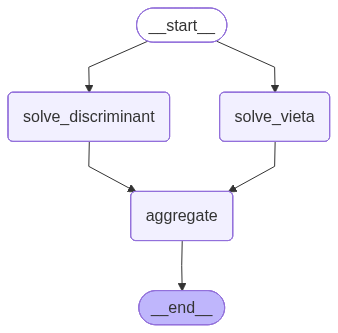

In [13]:
def solve_discriminant(state: MathState):
    llm = ChatOpenAI(
        model="gpt-5.4-mini", 
        temperature=0.0
        )    
    prompt = f"Реши квадратное уравнение через дискриминант шаг за шагом: {state['equation']}."
    res = llm.invoke(prompt)
    return {"disc_solution": res.content}

def solve_vieta(state: MathState):
    llm = ChatOpenAI(
        model="gpt-5.4-mini", 
        temperature=0.0
        )
    prompt = f"Реши квадратное уравнение через теорему Виета шаг за шагом: {state['equation']}."
    res = llm.invoke(prompt)
    return {"vieta_solution": res.content}

def aggregate(state: MathState):
    final = (
        f"Решение через дискриминант:\n{state['disc_solution']}\n\n"
        f"-------\n\n"
        f"Решение через теорему Виета:\n{state['vieta_solution']}"
    )
    return {"final_answer": final}

builder_math = StateGraph(MathState)
builder_math.add_node("solve_discriminant", solve_discriminant)
builder_math.add_node("solve_vieta", solve_vieta)
builder_math.add_node("aggregate", aggregate)

builder_math.add_edge(START, "solve_discriminant")
builder_math.add_edge(START, "solve_vieta")

builder_math.add_edge(["solve_discriminant", "solve_vieta"], "aggregate")
builder_math.add_edge("aggregate", END)

graph_math = builder_math.compile()

display(Image(graph_math.get_graph().draw_mermaid_png()))

In [14]:
eq = "x^2 - 2x + 10 = 0"
print(f"Решаем уравнение: {eq}\n")
out_math = graph_math.invoke({"equation": eq})
display(Markdown(out_math["final_answer"]))

Решаем уравнение: x^2 - 2x + 10 = 0



Решение через дискриминант:
Решим уравнение через дискриминант:

Дано:
\[
x^2 - 2x + 10 = 0
\]

## 1) Выпишем коэффициенты
Сравниваем с общим видом:
\[
ax^2 + bx + c = 0
\]

Тогда:
- \(a = 1\)
- \(b = -2\)
- \(c = 10\)

## 2) Найдём дискриминант
Формула:
\[
D = b^2 - 4ac
\]

Подставим:
\[
D = (-2)^2 - 4 \cdot 1 \cdot 10
\]
\[
D = 4 - 40 = -36
\]

## 3) Анализируем дискриминант
Так как
\[
D < 0
\]
то **действительных корней нет**.

## 4) Найдём корни в комплексных числах
Формула:
\[
x = \frac{-b \pm \sqrt{D}}{2a}
\]

Подставим:
\[
x = \frac{-(-2) \pm \sqrt{-36}}{2 \cdot 1}
\]
\[
x = \frac{2 \pm 6i}{2}
\]

\[
x = 1 \pm 3i
\]

## Ответ:
\[
\boxed{x_1 = 1 + 3i,\quad x_2 = 1 - 3i}
\]

Если хочешь, я могу ещё показать **проверку подстановкой**.

-------

Решение через теорему Виета:
Решим уравнение  
\[
x^2 - 2x + 10 = 0
\]
через теорему Виета.

### 1) Запишем коэффициенты
Для квадратного уравнения  
\[
x^2 + bx + c = 0
\]
по теореме Виета корни \(x_1\) и \(x_2\) должны удовлетворять:

\[
x_1 + x_2 = -b,\qquad x_1x_2 = c
\]

В нашем случае:

- \(b = -2\)
- \(c = 10\)

Значит:

\[
x_1 + x_2 = 2,\qquad x_1x_2 = 10
\]

### 2) Проверим, есть ли такие числа
Нужно найти два числа, которые:

- в сумме дают \(2\)
- в произведении дают \(10\)

Попробуем рассмотреть возможные пары множителей числа 10:

- \(1\) и \(10\) → сумма \(11\)
- \(2\) и \(5\) → сумма \(7\)
- \(-1\) и \(-10\) → сумма \(-11\)
- \(-2\) и \(-5\) → сумма \(-7\)

Ни одна пара не дает сумму \(2\).

### 3) Вывод
Значит, **действительных корней уравнение не имеет**, и через теорему Виета в целых или рациональных числах его разложить нельзя.

Если нужны **комплексные корни**, то можно решить так:
\[
x^2 - 2x + 10 = 0
\]
\[
D = (-2)^2 - 4\cdot 1 \cdot 10 = 4 - 40 = -36
\]
\[
x = \frac{2 \pm \sqrt{-36}}{2} = \frac{2 \pm 6i}{2} = 1 \pm 3i
\]

### Ответ:
\[
x_1 = 1 + 3i,\qquad x_2 = 1 - 3i
\]

Если хочешь, я могу показать, **как понять по Виету сразу, что действительных корней нет**, не перебирая пары.

<p class="task" id="3"></p>

3\. Вам дано два фрагмента текста. В одном из говорится, почему автор любит котиков, а в другом - почему автор любит собачек. При помощи `langchain` реализуйте систему, которая должна определить животное, выделить причину любви автора и, в зависимости от результата, "ответить" на соответствующем языке (кошачьем или собачьем).

Требования к решению:
- состояние графа должна хранить входной текст, объект классификации и итоговую реплику
- модель, которая классифицирует любимое животная, должна возвращать структурирированный объект (используйте `pydantic`) с видом животного (собака / кошка) и причиной любви

```json
{
    "animal": "КОШКА",
    "reason": "..."
}
```

- граф имеет условные ребра для генерации итогового сообщения, поток вычислений определяется видом животного



Выведите на экран графовое представление итогового конвейера. Продемонстрируйте работу на данных примерах.


- [x] Проверено на семинаре

In [15]:
cats_lover_msg = "Я обожаю кошек за их независимый характер и мягкие шершащие лапки, которые всегда радуют меня своим прикосновением."
dogs_lover_msg = "Собак я люблю за их преданность и энергичность, которые делают каждую прогулку незабываемой и полной веселья."

In [16]:
class AnimalReason(BaseModel):
    animal: Literal["КОШКА", "СОБАКА"] = Field(description="Животное, упомянутое в тексте (КОШКА или СОБАКА)")
    reason: str = Field(description="Причина, почему автор любит это животное")

class PetState(TypedDict):
    text: str
    animal: str
    reason: str
    reply: str

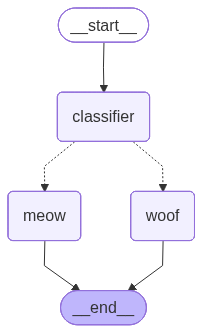

In [17]:
def classify_and_extract(state: PetState):
    llm = ChatOpenAI(
        model="gpt-5.4-mini",
        temperature=0
        )
    structured_llm = llm.with_structured_output(AnimalReason)
    res = structured_llm.invoke(state["text"])
    return {"animal": res.animal, "reason": res.reason}

def meow_node(state: PetState):
    return {"reply": f"Мяу! Человек уважает меня за: {state['reason']}."}

def woof_node(state: PetState):
    return {"reply": f"Гав! Человек обожает меня за: {state['reason']}."}

def route_animal(state: PetState):
    if state["animal"] == "КОШКА":
        return "meow"
    return "woof"

builder_pet = StateGraph(PetState)
builder_pet.add_node("classifier", classify_and_extract)
builder_pet.add_node("meow", meow_node)
builder_pet.add_node("woof", woof_node)

builder_pet.add_edge(START, "classifier")
builder_pet.add_conditional_edges(
    "classifier", 
    route_animal, 
    {"meow": "meow", "woof": "woof"}
)
builder_pet.add_edge("meow", END)
builder_pet.add_edge("woof", END)

graph_pet = builder_pet.compile()

display(Image(graph_pet.get_graph().draw_mermaid_png()))


In [18]:
msgs = [
    cats_lover_msg,
    dogs_lover_msg
]

for msg in msgs:
    print(f"\nВходной текст: {msg}")
    out = graph_pet.invoke({"text": msg})
    print(f"Ответ: {out['reply']}")


Входной текст: Я обожаю кошек за их независимый характер и мягкие шершащие лапки, которые всегда радуют меня своим прикосновением.
Ответ: Мяу! Человек уважает меня за: Потому что автор любит её за независимый характер и мягкие лапки, которые приятно ощущать при прикосновении..

Входной текст: Собак я люблю за их преданность и энергичность, которые делают каждую прогулку незабываемой и полной веселья.
Ответ: Гав! Человек обожает меня за: за их преданность и энергичность, которые делают каждую прогулку незабываемой и полной веселья.


<p class="task" id="4"></p>

4\. Вам дано 2 источника информации об магазине электроники:
- база данных, содержащая информацию о статусах заказов
- FAQ, содержащий ответы на самые частые вопросы

Требуется разработать систему с применением `langgraph`, которая работает следующим образом:
- классифицирует запрос (информация о статусе, технический вопрос, другое)
- если запрос информации о статусе, то при помощи соответствующего инструмента (функции) агент выполняет запрос к базе данных и выдает ответ
- если вопрос технический, то агент с применением технологии RAG для поиска по FAQ отвечает на вопрос
- если вопрос не относится к этим категориям, то агент пытается ответить самостоятельно

Продемонстрируйте примеры работы системы.



- [ ] Проверено на семинаре

In [30]:
loader = TextLoader("data/faq.txt", encoding="utf-8")
raw_docs = loader.load()
splitter = RecursiveCharacterTextSplitter(chunk_size=500, chunk_overlap=50)
faq_chunks = splitter.split_documents(raw_docs)

embeddings = HuggingFaceEmbeddings(
    model_name="sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2",
    encode_kwargs={"normalize_embeddings": True}
)
vectorstore = Chroma.from_documents(faq_chunks, embeddings)
retriever = vectorstore.as_retriever(search_kwargs={"k": 3})

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [31]:
DB_PATH = "data/orders.db"

pd.read_sql("SELECT * FROM orders", sqlite3.connect(DB_PATH))

,order_id,customer_name,status,item,delivery_date
0,101,Иван Иванов,Доставлен,iPhone 15,2023-10-20
1,102,Петр Сидоров,В пути,MacBook Air M2,2023-10-25
2,103,Мария Петрова,Обрабатывается,AirPods Pro,Ожидается подтверждение
3,777,Джеймс Бонд,Засекречено,Aston Martin DB5,2024-01-01


In [ ]:
class RouterOutput(BaseModel):
    category: Literal["status", "faq", "other"] = Field(
        description="Категория запроса: 'status', 'faq' или 'other'"
    )
    order_id: str = Field(
        default="", 
        description="Номер заказа (только цифры). Если номера нет, верни пустую строку ''."
    )
    
    
class StoreState(TypedDict):
    query: str
    category: str
    order_id: Optional[str]
    context: str
    response: str

def store_router(state: StoreState):
    """
    Одновременно классифицирует запрос и извлекает номер заказа (Entity Extraction).
    """

def store_router(state: StoreState):
    """
    Одновременно классифицирует запрос и извлекает номер заказа.
    Использует жесткий системный промпт для устранения галлюцинаций.
    """
    llm = ChatOpenAI(
        model="gpt-5.4-mini",
        temperature=0
    ).with_structured_output(RouterOutput)
    messages = [
        ("system", (
            "Ты — интеллектуальный диспетчер магазина электроники.\n"
            "Твоя задача — классифицировать запрос и извлекать данные.\n\n"
            "КАТЕГОРИИ:\n"
            "1. 'status' — клиент спрашивает, где его заказ, просит проверить доставку.\n"
            "2. 'faq' — технические вопросы, правила магазина (гарантия, возврат, часы работы).\n"
            "3. 'other' — просьбы посоветовать товар (например, подарок), отвлеченное общение (привет, как дела).\n\n"
            "ПРАВИЛА ИЗВЛЕЧЕНИЯ НОМЕРА ЗАКАЗА (order_id):\n"
            "Если категория 'status', найди номер заказа. Игнорируй количество товаров (например, '2 телефона'). "
            "Номер заказа обычно стоит рядом со словами 'заказ', 'номер'. "
            "Если номера нет или категория не 'status', верни пустую строку ''."
        )),
        ("human", state['query'])
    ]
    
    res = llm.invoke(messages)
    return {"category": res.category, "order_id": res.order_id}


In [33]:
def order_status_node(state: StoreState):
    """Выполняет SQL-запрос к БД."""
    oid = state.get("order_id")
    
    if not oid or oid.strip() == "":
        return {"response": "Пожалуйста, укажите номер заказа в вашем запросе, чтобы я мог проверить его статус."}

    try:
        conn = sqlite3.connect(DB_PATH)
        cursor = conn.cursor()
        
        query_sql = "SELECT customer_name, item, status, delivery_date FROM orders WHERE order_id = ?"
        cursor.execute(query_sql, (oid,))
        result = cursor.fetchone()
        
        if result:
            customer_name, item, status, delivery_date = result
            response = (
                f"Здравствуйте, {customer_name}! "
                f"Ваш заказ #{oid} ({item}) сейчас в статусе: '{status}'. "
                f"Информация по доставке: {delivery_date}."
            )
        else:
            response = f"К сожалению, заказ с номером #{oid} не найден в нашей системе."
            
        conn.close()
    except sqlite3.Error as e:
        response = f"Произошла техническая ошибка при обращении к базе данных. Передайте код ошибки администратору: {e}"

    return {"response": response}

def faq_rag_node(state: StoreState):
    """Выполняет RAG поиск по FAQ и генерирует ответ."""
    if not retriever:
        return {"response": "База знаний FAQ временно недоступна."}
        
    docs = retriever.invoke(state["query"])
    context = "\n".join([d.page_content for d in docs])
    
    llm = ChatOpenAI(model="gpt-5.4-mini", temperature=0)
    prompt = (
        f"Ты сотрудник службы поддержки. Ответь на вопрос опираясь строго на предоставленный FAQ.\n\n"
        f"FAQ:\n{context}\n\nВопрос клиента: {state['query']}"
    )
    res = llm.invoke(prompt)
    return {"response": res.content, "context": context}

def general_chat_node(state: StoreState):
    """Ответ на свободные темы, не попадающие под RAG или статус заказа."""
    llm = ChatOpenAI(model="gpt-5.4-mini", temperature=0.7)
    res = llm.invoke(f"Пользователь: {state['query']}\nТы вежливый ассистент магазина электроники. Ответь пользователю.")
    return {"response": res.content}

def route_store(state: StoreState):
    """Маршрутизатор для графа."""
    return state["category"]

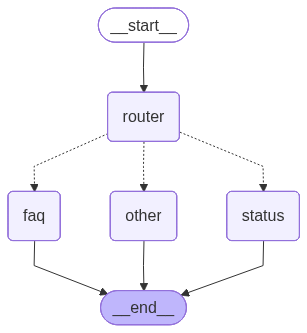


`USER`: Я заказал 2 телефона, подскажи статус моего заказа 101?

`SYSTEM - STATUS`: Здравствуйте, Иван Иванов! Ваш заказ #101 (iPhone 15) сейчас в статусе: 'Доставлен'. Информация по доставке: 2023-10-20.


`USER`: Что с моим заказом 777?

`SYSTEM - STATUS`: Здравствуйте, Джеймс Бонд! Ваш заказ #777 (Aston Martin DB5) сейчас в статусе: 'Засекречено'. Информация по доставке: 2024-01-01.


`USER`: А какая у вас гарантия на смартфоны?

`SYSTEM - FAQ`: На смартфоны, приобретенные в нашем магазине, распространяется стандартная гарантия сроком **24 месяца с даты покупки**.


`USER`: Привет, посоветуй хороший подарок для айтишника?

`SYSTEM - OTHER`: Привет! Конечно 🙂 Для айтишника обычно хорошо заходят подарки, которые либо реально полезны в работе, либо просто делают повседневную жизнь удобнее.

Вот несколько удачных вариантов:

**1. Механическая клавиатура**  
Если человек много печатает, это один из лучших подарков. Можно выбрать тихую модель для офиса или более “кликающую” для дома.

**2. Беспроводная мышь или трекпад**  
Хорошая мышь с точным сенсором и удобной формой — практичный и универсальный подарок.

**3. Гарнитура или наушники с шумоподавлением**  
Очень полезно для созвонов, работы в шумном офисе и просто для концентрации.

**4. Подставка для ноутбука**  
Помогает держать правильную высоту экрана и делать рабочее место комфортнее.

**5. Внешний SSD**  
Отличный подарок, если нужны быстрые переносы файлов, бэкапы или работа с большими проектами.

**6. USB-хаб / док-станция**  
Особенно актуально для ноутбуков с ограниченным количеством портов.

**7. Умная лампа или настольный светильник**  
Полезно для вечерней работы за компьютером и создания удобного рабочего места.

**8. Сертификат в магазин электроники**  
Если не знаешь точные предпочтения, это самый безопасный вариант — человек выберет сам.

Если хочешь, я могу помочь подобрать подарок **по бюджету** — например, до 3 000, 5 000 или 10 000 рублей.


`USER`: Как часто стоит менять термопасту?

`SYSTEM - FAQ`: Согласно FAQ, рекомендуется проводить чистку системы охлаждения и замену термопасты не реже одного раза в 1,5–2 года. Если ноутбук используется в пыльном помещении или рядом с домашними животными, срок обслуживания сокращается до 1 года.

In [36]:

builder_store = StateGraph(StoreState)

builder_store.add_node("router", store_router)
builder_store.add_node("status", order_status_node)
builder_store.add_node("faq", faq_rag_node)
builder_store.add_node("other", general_chat_node)

builder_store.add_edge(START, "router")
builder_store.add_conditional_edges(
    "router", 
    route_store, 
    {"status": "status", "faq": "faq", "other": "other"}
)
builder_store.add_edge("status", END)
builder_store.add_edge("faq", END)
builder_store.add_edge("other", END)

graph_store = builder_store.compile()
display(Image(graph_store.get_graph().draw_mermaid_png()))

queries = [
    "Я заказал 2 телефона, подскажи статус моего заказа 101?",
    "Что с моим заказом 777?",
    "А какая у вас гарантия на смартфоны?",
    "Привет, посоветуй хороший подарок для айтишника?", 
    "Как часто стоит менять термопасту?"
]

for q in queries:
    display(Markdown(f"\n`USER`: {q}"))
    out = graph_store.invoke({"query": q})
    display(Markdown(f"`SYSTEM - {out['category'].upper()}`: {out['response']}"))